# Tugas Mid Machine Learning II - IoT
**Kelompok 1**
* Muhammad Noval Surya Pratama (8020230284)
* Muhammad Daffa Auliyansyah (8020210242)

---

## Tahap 1: Persiapan dan Membaca Dataset
Pada tahap ini, kita akan mengimpor library yang dibutuhkan dan membaca dataset yang telah disiapkan (`Preprocessed Balanced dataset.csv`) ke dalam Pandas DataFrame.

In [1]:
# Mengimpor library
import pandas as pd
import numpy as np

# Membaca dataset
df = pd.read_csv('Preprocessed Balanced dataset.csv')

# Menampilkan 5 baris pertama untuk memastikan data masuk dengan benar
df.head()

,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


## Tahap 2: Eksplorasi Data Awal
Pada tahap ini, kita akan memeriksa struktur dataset, termasuk jumlah baris dan kolom, tipe data setiap fitur, serta mengecek apakah terdapat nilai yang kosong (*missing values*) di dalam dataset.

In [2]:
# Melihat jumlah baris dan kolom secara keseluruhan
print("Ukuran dataset (Baris, Kolom):", df.shape)
print("-" * 50)

# Melihat informasi detail tentang tipe data dan apakah ada data yang kosong (null)
df.info()

Ukuran dataset (Baris, Kolom): (1048575, 88)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                         

## Tahap 3: Analisis Distribusi Label (Target Variable)
Pada tahap ini, kita akan mengecek distribusi dari kolom target untuk melihat keseimbangan kelas pada dataset ini. Kita akan mengecek kolom `Label` dan `Attack_Category`.

In [3]:
# Melihat jumlah data pada masing-masing kelas di kolom 'Label'
print("Distribusi pada kolom 'Label':")
print(df['Label'].value_counts())
print("\n" + "="*50 + "\n")

# Melihat jumlah data pada masing-masing kategori serangan
print("Distribusi pada kolom 'Attack_Category':")
print(df['Attack_Category'].value_counts())

Distribusi pada kolom 'Label':
Label
1    959925
0     88650
Name: count, dtype: int64


Distribusi pada kolom 'Attack_Category':
Attack_Category
0    354600
3    177300
6    162075
5     88650
2     88650
4     88650
1     88650
Name: count, dtype: int64


## Tahap 4: Visualisasi Distribusi Kelas
Pada tahap ini, kita akan membuat visualisasi berupa diagram batang (*bar chart*) untuk melihat perbandingan jumlah data normal dan data serangan (kolom `Label`) agar ketidakseimbangan data (*imbalance*) terlihat lebih jelas.

C:\Users\noval\AppData\Local\Temp\ipykernel_178220\3300812619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='Set2')


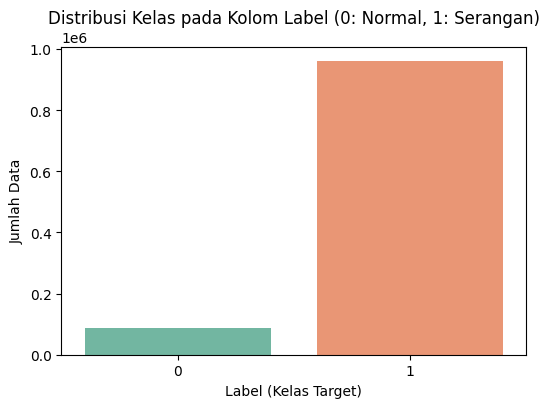

In [4]:
# Mengimpor library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran kanvas gambar
plt.figure(figsize=(6, 4))

# Membuat diagram batang
sns.countplot(data=df, x='Label', palette='Set2')

# Menambahkan judul dan label
plt.title('Distribusi Kelas pada Kolom Label (0: Normal, 1: Serangan)')
plt.xlabel('Label (Kelas Target)')
plt.ylabel('Jumlah Data')

# Menampilkan gambar
plt.show()

## Tahap 5: Pemisahan Fitur (X) dan Target (y)
Pada tahap ini, kita akan memisahkan dataset menjadi dua bagian:
* **X (Fitur):** Kolom-kolom yang berisi karakteristik data jaringan (kecuali kolom target).
* **y (Target):** Kolom `Label` yang menjadi penentu apakah data tersebut Normal (0) atau Serangan (1).

Kita juga perlu membuang kolom `Attack_Category` dan `Attack_sub_category` dari variabel X agar model tidak mengalami kebocoran data (*data leakage*).

### Analisis Pembuangan Fitur (Pencegahan Data Leakage)
Sebelum memisahkan data menjadi fitur (X) dan target (y), kita melakukan penghapusan (drop) pada kolom `Label` sebagai target prediksi, serta kolom `Attack_Category` dan `Attack_sub_category`. 

**Alasan pembuangan fitur kategori serangan:** Kedua kolom tersebut merupakan turunan langsung dari target prediksi (bocoran jawaban). Jika fitur ini ikut dimasukkan ke dalam tahap pelatihan, model akan mengalami **Data Leakage**. Model akan mencapai akurasi tinggi karena "menghafal" kategori serangannya, bukan mempelajari pola metrik jaringan yang sesungguhnya. Untuk memastikan simulasi *deployment* yang realistis di mana kategori serangan belum diketahui oleh sistem di awal, kedua kolom ini wajib dieliminasi.

In [5]:
# Menentukan Fitur (X) dengan membuang kolom yang berisi label/jawaban
X = df.drop(columns=['Label', 'Attack_Category', 'Attack_sub_category'])

# Menentukan Target (y)
y = df['Label']

# Mengecek ukuran X dan y yang baru saja dibuat
print("Ukuran X (Fitur):", X.shape)
print("Ukuran y (Target):", y.shape)

Ukuran X (Fitur): (1048575, 85)
Ukuran y (Target): (1048575,)


## Tahap 6: Pembagian Data Latih dan Uji (Train-Test Split)
Pada tahap ini, kita akan membagi dataset menjadi dua bagian: data untuk melatih model (*Training Data*) dan data untuk menguji performa model (*Testing Data*). Kita akan menggunakan rasio 80% untuk *training* dan 20% untuk *testing*. Kita juga menggunakan parameter `stratify` agar proporsi data serangan dan data normal tetap seimbang di kedua bagian tersebut.

In [6]:
# Mengimpor library untuk membagi data
from sklearn.model_selection import train_test_split

# Membagi data (80% Training, 20% Testing)
# random_state=42 memastikan agar acakannya selalu sama setiap kali di-run
# stratify=y memastikan rasio kelas 0 dan 1 tetap sama di data latih maupun data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan ukuran data setelah dibagi
print("Ukuran X_train (Buku Latihan):", X_train.shape)
print("Ukuran X_test (Soal Ujian):", X_test.shape)
print("Ukuran y_train (Kunci Jawaban Latihan):", y_train.shape)
print("Ukuran y_test (Kunci Jawaban Ujian):", y_test.shape)

Ukuran X_train (Buku Latihan): (838860, 85)
Ukuran X_test (Soal Ujian): (209715, 85)
Ukuran y_train (Kunci Jawaban Latihan): (838860,)
Ukuran y_test (Kunci Jawaban Ujian): (209715,)


## Tahap 7: Pelatihan Model dan Optimasi (Hyperparameter Tuning)
Pada tahap ini, kita tidak hanya melatih algoritma **Decision Tree**, tetapi juga mencari pengaturan (*hyperparameter*) terbaiknya agar model tidak *overfitting*. Karena ukuran data sangat besar, kita menggunakan **RandomizedSearchCV** untuk mencari kombinasi parameter terbaik secara efisien tanpa membebani komputasi secara berlebihan.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Menentukan daftar 'settingan'
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_base = DecisionTreeClassifier(random_state=42)

# 2. MENGUBAH PENGATURAN AGAR TIDAK CRASH (Versi Super Ringan)
mesin_pencari = RandomizedSearchCV(
    estimator=dt_base, 
    param_distributions=param_grid,
    n_iter=3,        # Dikurangi dari 5 menjadi 3 percobaan saja
    cv=2,            # Ujian silang dikurangi dari 3 menjadi 2
    scoring='f1_macro', 
    n_jobs=1,        # DIUBAH JADI 1: Mencegah prosesor Windows bentrok/macet
    random_state=42
)

# 3. Memulai proses belajar
print("Sedang mencari parameter terbaik versi ringan... (Mohon tunggu sebentar)")
mesin_pencari.fit(X_train, y_train)

print("\nStatus: Pencarian selesai dengan aman!")
print("Kombinasi parameter terbaik:", mesin_pencari.best_params_)

# 4. Menyimpan model terbaik
best_model_dt = mesin_pencari.best_estimator_

Sedang mencari parameter terbaik versi ringan... (Mohon tunggu sebentar)

Status: Pencarian selesai dengan aman!
Kombinasi parameter terbaik: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}


## Tahap 8: Evaluasi Akhir (Test Set)
Pada tahap ini, kita melakukan evaluasi akhir menggunakan data testing (`X_test` dan `y_test`). Kita akan menampilkan metrik performa melalui Laporan Klasifikasi (*Classification Report*) dan visualisasi **Confusion Matrix**. Terakhir, model yang telah dilatih akan disimpan ke dalam format `.pkl` menggunakan library `joblib` agar dapat digunakan kembali (*deployment*).

=== LAPORAN KLASIFIKASI (MODEL TUNING) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17730
           1       1.00      1.00      1.00    191985

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715


Menampilkan Visualisasi Confusion Matrix...


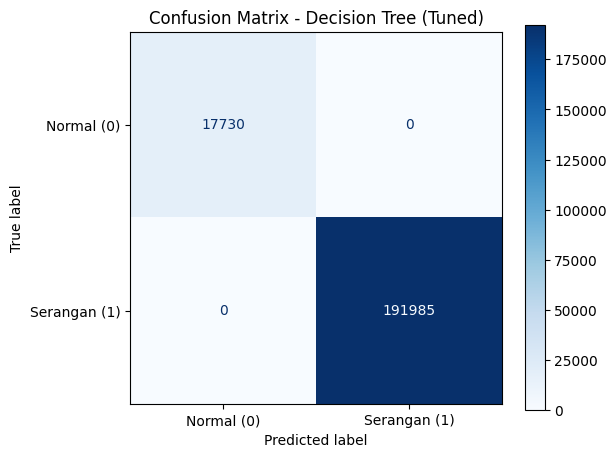


[SUKSES] Model terbaik telah disimpan dengan nama: pipeline_terbaik.pkl


In [9]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Prediksi menggunakan model TERBAIK hasil tuning (best_model_dt)
y_pred = best_model_dt.predict(X_test)

# 2. Laporan Klasifikasi
print("=== LAPORAN KLASIFIKASI (MODEL TUNING) ===")
print(classification_report(y_test, y_pred))
print("="*42 + "\n")

# 3. Visualisasi Confusion Matrix
print("Menampilkan Visualisasi Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Serangan (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Decision Tree (Tuned)')
plt.show()

# 4. Simpan Model Terbaik
nama_file_model = 'pipeline_terbaik.pkl'
joblib.dump(best_model_dt, nama_file_model)
print(f"\n[SUKSES] Model terbaik telah disimpan dengan nama: {nama_file_model}")